# Internship Project 3: Landmark Classification for Places using TensorFlow

This project classifies images of places into different landmark categories such as Gothic, Modern, Mughal, Neoclassical, Pagodas,
and Pyramids using TensorFlow and transfer learning.
Dataset from kaggle-https://www.kaggle.com/datasets/kayvanshah/landmarks-dataset

## Project Description

This project focuses on landmark classification for places using deep learning in TensorFlow. 
The objective is to build an image classification model that can identify different types of architectural landmarks and places from images.

The dataset used for this project was obtained from Kaggle and consists of images grouped into different landmark categories such
as Gothic, Modern, Mughal, Neoclassical, Pagodas, and Pyramids. Each class represents a specific architectural or place-based landmark style.

In this project, the images are loaded, preprocessed, and divided into training and validation sets. 
A transfer learning approach is used with the MobileNetV2 pretrained model to extract meaningful image features. 
The final classification layer is then trained to recognize the place landmark categories.

The workflow of the project includes:
- Loading the dataset from class-wise folders
- Removing invalid or corrupted files
- Visualizing sample images
- Applying image preprocessing and augmentation
- Building and training a TensorFlow model
- Evaluating model performance using validation accuracy and loss
- Predicting landmark classes on unseen images

This project demonstrates the use of TensorFlow for image-based landmark classification and highlights the effectiveness of
transfer learning in real-world image recognition tasks.

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


# 1. CONFIG

In [16]:
DATASET_DIR = r"D:\desktop\archive" 
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

print("Dataset exists:", os.path.exists(DATASET_DIR))
print("Folders found:", os.listdir(DATASET_DIR))

Dataset exists: True
Folders found: ['Gothic', 'Modern', 'Mughal', 'Neoclassical', 'Pagodas', 'Pyramids']


# 2. REMOVE BAD / CORRUPTED IMAGES

In [18]:


IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")
removed_count = 0
checked_count = 0

for root, dirs, files in os.walk(DATASET_DIR):
    for file_name in files:
        file_path = os.path.join(root, file_name)

        if not file_name.lower().endswith(IMAGE_EXTENSIONS):
            os.remove(file_path)
            removed_count += 1
            continue

        try:
            raw = tf.io.read_file(file_path)
            image = tf.image.decode_image(raw, channels=3)
            checked_count += 1
        except Exception:
            os.remove(file_path)
            removed_count += 1

print(f"Checked: {checked_count} images")
print(f"Removed: {removed_count} bad/corrupted files")


Checked: 417 images
Removed: 0 bad/corrupted files


# 3. LOAD DATASET

In [19]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


Found 417 files belonging to 6 classes.
Using 334 files for training.
Found 417 files belonging to 6 classes.
Using 83 files for validation.
Class names: ['Gothic', 'Modern', 'Mughal', 'Neoclassical', 'Pagodas', 'Pyramids']
Number of classes: 6


# 4. VISUALIZE SAMPLE IMAGES

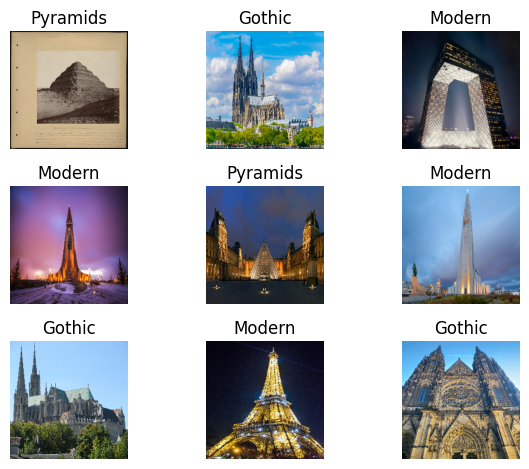

In [20]:

for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()


# 5. DATA AUGMENTATION

In [21]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])


# 6. BUILD MODEL

In [23]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# 7. COMPILE MODEL

In [24]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 8. CALLBACKS

In [25]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_place_landmark_classifier.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]


# 9. TRAIN MODEL

In [26]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.1707 - loss: 2.1306 - val_accuracy: 0.2530 - val_loss: 1.6602
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.3683 - loss: 1.6453 - val_accuracy: 0.4819 - val_loss: 1.3862
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.4701 - loss: 1.4132 - val_accuracy: 0.6265 - val_loss: 1.1679
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.5928 - loss: 1.1403 - val_accuracy: 0.7711 - val_loss: 0.9866
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.6886 - loss: 0.9512 - val_accuracy: 0.8434 - val_loss: 0.8495
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.7275 - loss: 0.8083 - val_accuracy: 0.8554 - val_loss: 0.7483
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.7784 - loss: 0.7150 - val_accuracy: 0.8675 - val_loss: 0.6660
Epoch 8/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.8293 - loss: 0.6332 - val_accuracy: 0.8795 - val_loss:

# 10. PLOT TRAINING HISTORY

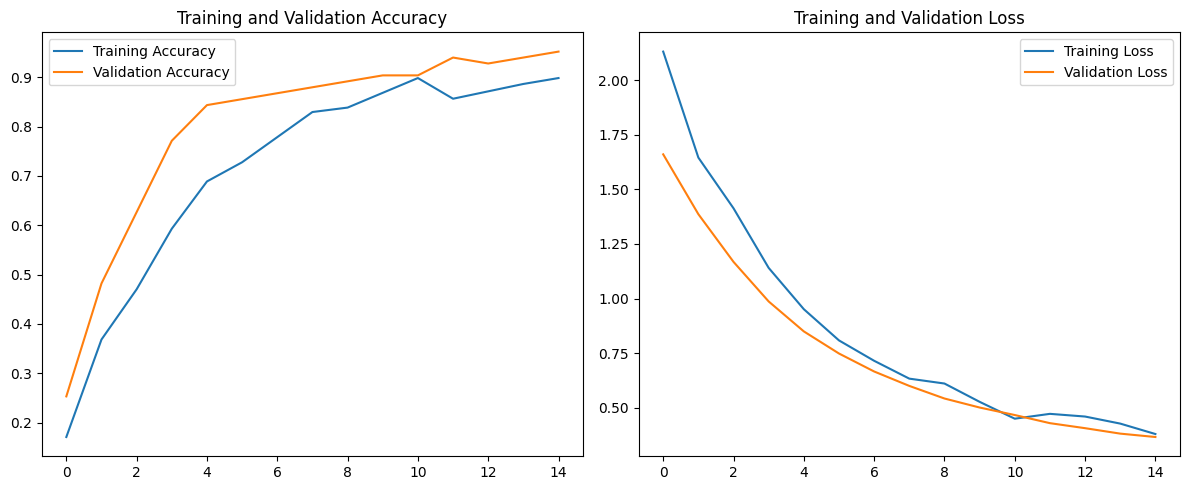

In [27]:
def plot_history(history):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Training Accuracy")
    plt.plot(epochs_range, val_acc, label="Validation Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Training Loss")
    plt.plot(epochs_range, val_loss, label="Validation Loss")
    plt.title("Training and Validation Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

# 11. EVALUATE MODEL

In [28]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9518 - loss: 0.3660
Validation Loss: 0.3660
Validation Accuracy: 0.9518


# 12. SHOW SAMPLE PREDICTIONS

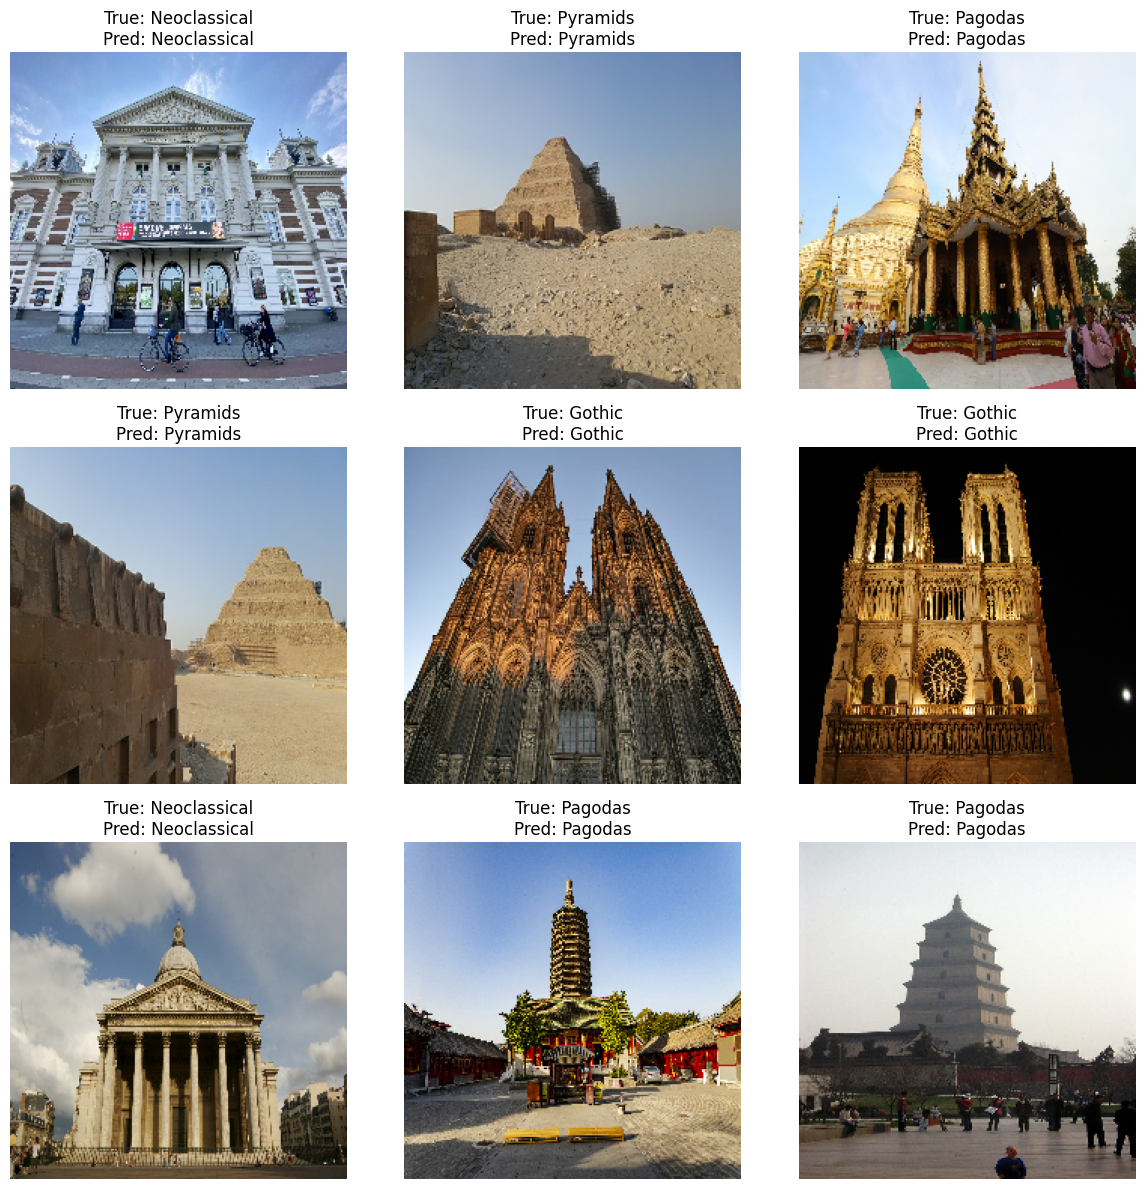

In [29]:
plt.figure(figsize=(12, 12))
for images, labels in val_ds.take(1):
    predictions = model.predict(images, verbose=0)
    pred_labels = np.argmax(predictions, axis=1)

    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_label = class_names[labels[i]]
        pred_label = class_names[pred_labels[i]]
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis("off")

plt.tight_layout()
plt.show()

# 13. SINGLE IMAGE PREDICTION

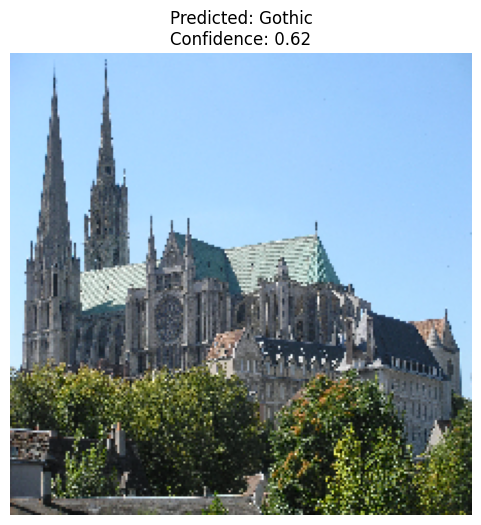

In [35]:
def predict_landmark(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    prediction = model.predict(img_array, verbose=0)
    pred_index = np.argmax(prediction[0])
    confidence = np.max(prediction[0])

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Predicted: {class_names[pred_index]}\nConfidence: {confidence:.2f}")
    plt.axis("off")
    plt.show()

predict_landmark(r"D:\desktop\archive\Gothic\ChartresCathedral\ChartresCathedral0.jpeg")